# SmartReads: Genre‑Specific Recommender
Content‑based filtering with **TF‑IDF + Cosine** over `bookDesc + bookGenres`,
then ranking by a weighted mix of **similarity**, **popularity** (ratingCount + reviewCount), and **quality** (bookRating).


In [18]:
import pandas as pd, numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
url = 'https://raw.githubusercontent.com/adobamenphoebe/smartreads-book-recommender/main/data/raw/goodreads_genre_clean_5k.csv'
df = pd.read_csv(url, dtype=str)
df.head(3)

,url,bookTitle,bookImage,bookAuthors,bookDesc,bookRating,ratingCount,reviewCount,bookPages,bookGenres,bookISBN,recommendations
0,https://www.goodreads.com/book/show/2767052-th...,The Hunger Games,https://i.gr-assets.com/images/S/compressed.ph...,Suzanne Collins,"Could you survive on your own in the wild, wit...",4.32,6717635,176054,374 pages,"Young Adult/31,498|Fiction/17,878|Science Fict...",9780439023481.0,"['Divergent (Divergent, #1)|https://www.goodre..."
1,https://www.goodreads.com/book/show/2.Harry_Po...,Harry Potter and the Order of the Phoenix,https://i.gr-assets.com/images/S/compressed.ph...,"J.K. Rowling,Mary GrandPré",There is a door at the end of a silent corrido...,4.5,2668409,45724,870 pages,"Fantasy/1,797|Young Adult/15,961|Fiction/14,15...",NaN,['Harry Potter and the Cursed Child: Parts One...
2,https://www.goodreads.com/book/show/2657.To_Ki...,To Kill a Mockingbird,https://i.gr-assets.com/images/S/compressed.ph...,Harper Lee,The unforgettable novel of a childhood in a sl...,4.28,4772918,95595,324 pages,"Classics/47,203|Fiction/23,575|Historical-Hist...",NaN,['The Great Gatsby|https://www.goodreads.com/b...


## Filter by genre

In [19]:
GENRE_COL = 'bookGenres'
DESC_COL = 'bookDesc'
TITLE_COL = 'bookTitle'
df_sci = df[df[GENRE_COL].astype(str).str.lower().str.contains('science fiction', na=False)]
len(df_sci)

1068

## Build TF‑IDF (genres emphasized)

In [20]:
genres = (
    df_sci[GENRE_COL]
    .fillna('')
    .astype(str)
    .str.replace(r"[\[\]'\"\\]", '', regex=True)
    .str.replace(',', ' ', regex=False)
)


## Rank by similarity + popularity + quality

In [21]:
def rank(df_filt, X, query_text=None, topk=10, weights=(0.6,0.25,0.15)):
    from sklearn.feature_extraction.text import TfidfVectorizer
    if query_text:
        tfidf_local = TfidfVectorizer(stop_words='english', max_features=50000, ngram_range=(1,2))
        X_local = tfidf_local.fit_transform(combined)
        qv = tfidf_local.transform([query_text])
        sim = cosine_similarity(qv, X_local).ravel()
    else:
        sim = np.zeros(len(df_filt))
    RC_COL = 'ratingCount'
    REV_COL = 'reviewCount'
    RATING_COL = 'bookRating'
    pop = df_filt[[c for c in [RC_COL, REV_COL] if c in df_filt.columns]].apply(pd.to_numeric, errors='coerce').fillna(0.0).sum(axis=1).values.reshape(-1,1)
    pop = MinMaxScaler().fit_transform(pop).ravel() if len(pop) else np.zeros(len(df_filt))
    qual = pd.to_numeric(df_filt[RATING_COL], errors='coerce').fillna(0.0).values.reshape(-1,1)
    qual = MinMaxScaler().fit_transform(qual).ravel()
    w_sim, w_pop, w_qual = weights
    score = w_sim*sim + w_pop*pop + w_qual*qual
    order = np.argsort(-score)[:topk]
    cols = [c for c in ['bookTitle','bookAuthors', GENRE_COL, RATING_COL, RC_COL, REV_COL] if c in df_filt.columns]
    out = df_filt.iloc[order][cols].copy()
    out['score'] = score[order]
    return out

rank(df_sci, X, query_text='space opera', topk=5)

,bookTitle,bookAuthors,bookGenres,bookRating,ratingCount,reviewCount,score
37,Harry Potter and the Sorcerer's Stone,"J.K. Rowling,Mary GrandPré","Fantasy/64,335|Fiction/19,378|Young Adult/18,9...",4.48,7550262,119673,0.371084
3736,The Hunger Games,Suzanne Collins,"Young Adult/31,498|Fiction/17,878|Science Fict...",4.32,6717835,176060,0.331331
0,The Hunger Games,Suzanne Collins,"Young Adult/31,498|Fiction/17,878|Science Fict...",4.32,6717635,176054,0.331325
1786,Second Foundation,Isaac Asimov,"Science Fiction/4,521|Fiction/1,523|Classics/3...",4.25,153049,2849,0.245951
3978,The Vor Game,Lois McMaster Bujold,"Science Fiction/1,067|Space-Space Opera/246|Fi...",4.26,22479,815,0.241679


## Visualization Results
Visualizations highlighting genre trends, rating patterns, and recommendation transparency.


In [22]:
# Build a clean "mainGenre" = first tag only, drop any "/123" counts
def first_genre_only(s: str) -> str:
    s = str(s)
    first_token = s.split('|')[0]              # take first genre chunk
    name_only = first_token.split('/')[0]      # remove trailing "/count"
    return name_only.strip()

df['mainGenre'] = df[GENRE_COL].astype(str).apply(first_genre_only)


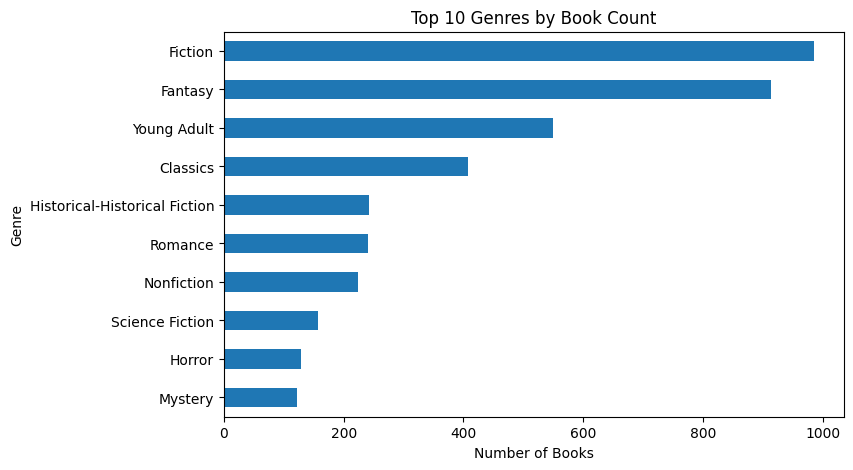

In [23]:
import matplotlib.pyplot as plt

top_counts = df['mainGenre'].value_counts().head(10)

plt.figure(figsize=(8,5))
top_counts.plot(kind='barh')
plt.title('Top 10 Genres by Book Count')
plt.xlabel('Number of Books')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.show()


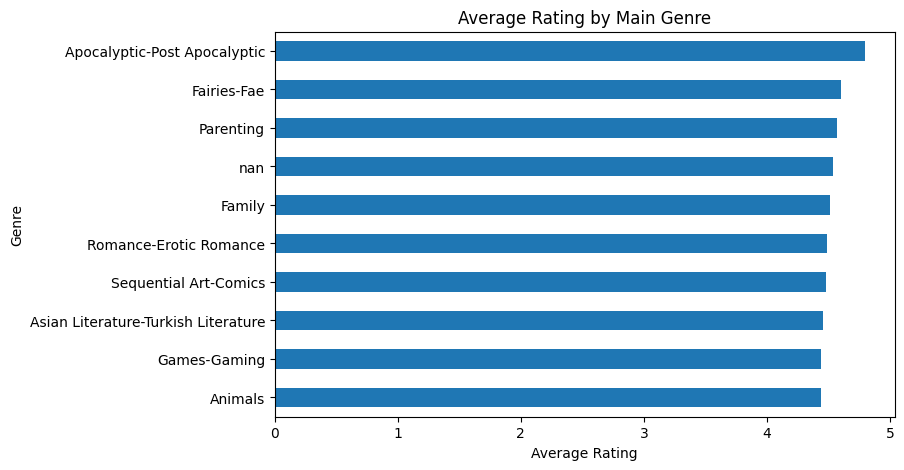

In [24]:
# ensure numeric ratings
df['bookRating'] = pd.to_numeric(df['bookRating'], errors='coerce')

avg_rating_by_genre = (
    df.groupby('mainGenre')['bookRating']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(8,5))
avg_rating_by_genre.plot(kind='barh')
plt.title('Average Rating by Main Genre')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.show()


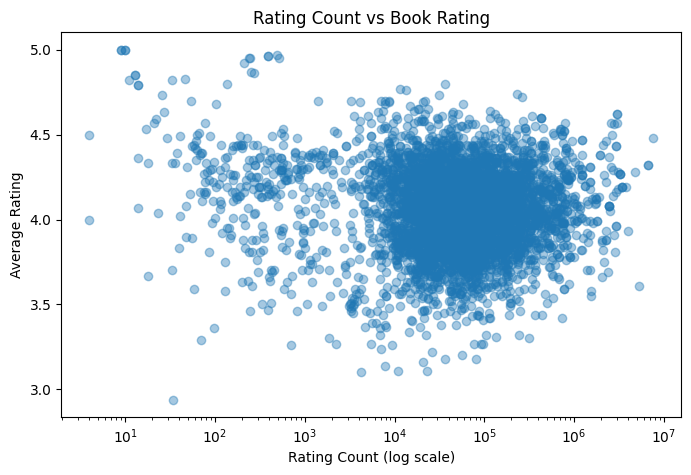

In [25]:
x = pd.to_numeric(df['ratingCount'], errors='coerce')
y = pd.to_numeric(df['bookRating'], errors='coerce')
mask = x.notna() & y.notna()

plt.figure(figsize=(8,5))
plt.scatter(x[mask], y[mask], alpha=0.4)
plt.xscale('log')
plt.title('Rating Count vs Book Rating')
plt.xlabel('Rating Count (log scale)')
plt.ylabel('Average Rating')
plt.show()


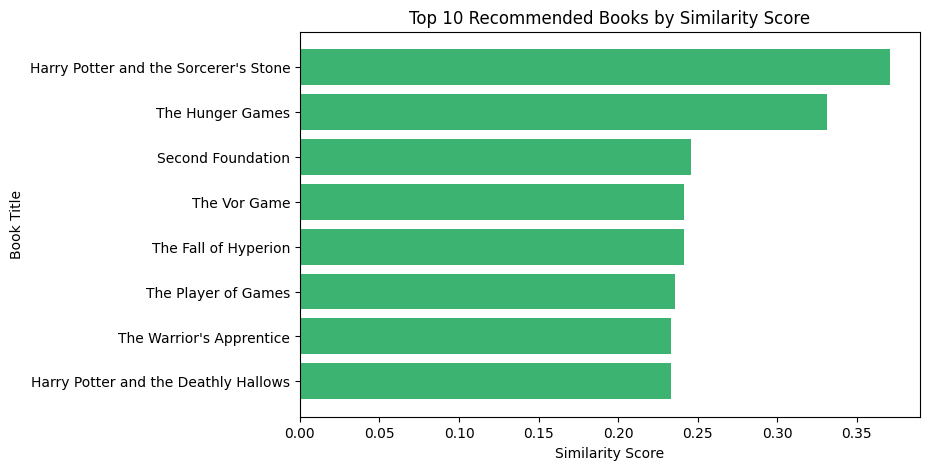

In [26]:
recs = rank(df_sci, X, query_text='space opera', topk=10)

plt.figure(figsize=(8,5))
plt.barh(recs['bookTitle'], recs['score'], color='mediumseagreen')
plt.title('Top 10 Recommended Books by Similarity Score')
plt.xlabel('Similarity Score')
plt.ylabel('Book Title')
plt.gca().invert_yaxis()
plt.show()
